In [ ]:
!pip install seaborn
!pip install matplotlib
!pip install pandas

In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [5]:
df = pd.read_csv(r'/Users/krishikasandiri/Desktop/ds-studio-ii:/datasets/background survey.csv')

Cleaning: Removing Duplicates

In [7]:
df[df['What is your name?'].duplicated(keep=False)]
#.sum()

,Timestamp,What is your name?,Did you grow up in North Carolina?,How old are you?,What level of a student are you?,"How familiar are you with ""data science""?","How familiar are you with ""social science""",How nervous are you for this class?,Are you excited for this class?,"How do you think generative AI should be used or treated in this course? Don't be shy, we're looking for honest, insightful ideas,"
2,2026/01/11 8:29:18 PM EST,First Last 3,No,21,Junior,4,5,3,Yes,I don't think we should rely on it. I think it...
5,2026/01/12 8:59:36 AM EST,NaN,Yes,18,Sophomore,4,4,5,Yes,I feel it should be used to study and check yo...
13,2026/01/12 9:17:17 AM EST,First Last 13,No,19,Sophomore,3,3,3,Yes,"To support students to do their project, give ..."
22,2026/01/12 9:21:34 AM EST,NaN,Yes,19,Sophomore,4,3,2,Yes,I think generative AI should be used as a seco...
27,2026/01/12 9:39:06 AM EST,First Last 26,Yes,30,Sophomore,3,2,1,Yes,I think generative AI should be universally us...
37,2026/01/12 9:46:19 AM EST,First Last 36,No,20,Junior,4,2,3,Yes,only as a tool for help learning
38,2026/01/12 9:47:48 AM EST,First Last 3,No,21,Junior,4,5,3,Yes,I think it is a very thin line on using AI. AI...
39,2026/01/12 9:47:58 AM EST,First Last 36,No,20,Junior,4,2,3,Yes,Only as tool for help learning
46,2026/01/12 10:21:47 AM EST,First Last 43,Yes,19,Sophomore,4,3,5,Yes,I think AI is very useful for debugging but I ...
51,2026/01/12 10:24:07 AM EST,NaN,Yes,18,Freshman,2,3,4,Maybe,Should be used to help answer questions but be...


Decisions: Keep the most recent one, drop earlier submissions for duplicate names.
Notes: We don't want to remove NaNs. We notice that all the submissions seem relatively unique, so we all will keep those and we are assuming they are all individuals.

In [9]:
duplicates = df[df['What is your name?'].duplicated(keep=False)] 
duplicates.sort_values(by='What is your name?')
# df[something]

,Timestamp,What is your name?,Did you grow up in North Carolina?,How old are you?,What level of a student are you?,"How familiar are you with ""data science""?","How familiar are you with ""social science""",How nervous are you for this class?,Are you excited for this class?,"How do you think generative AI should be used or treated in this course? Don't be shy, we're looking for honest, insightful ideas,"
13,2026/01/12 9:17:17 AM EST,First Last 13,No,19,Sophomore,3,3,3,Yes,"To support students to do their project, give ..."
92,2026/01/13 2:34:12 PM EST,First Last 13,Yes,19,Sophomore,3,3,4,Yes,Be mroe effecient with data
27,2026/01/12 9:39:06 AM EST,First Last 26,Yes,30,Sophomore,3,2,1,Yes,I think generative AI should be universally us...
66,2026/01/12 10:34:45 AM EST,First Last 26,Yes,30,Sophomore,3,2,5,Yes,Sorry if this is a duplicate submission (if it...
2,2026/01/11 8:29:18 PM EST,First Last 3,No,21,Junior,4,5,3,Yes,I don't think we should rely on it. I think it...
38,2026/01/12 9:47:48 AM EST,First Last 3,No,21,Junior,4,5,3,Yes,I think it is a very thin line on using AI. AI...
37,2026/01/12 9:46:19 AM EST,First Last 36,No,20,Junior,4,2,3,Yes,only as a tool for help learning
39,2026/01/12 9:47:58 AM EST,First Last 36,No,20,Junior,4,2,3,Yes,Only as tool for help learning
95,2026/01/13 9:23:32 PM EST,First Last 36,No,20,Junior,4,2,3,Yes,Only as a tool for help better learning
46,2026/01/12 10:21:47 AM EST,First Last 43,Yes,19,Sophomore,4,3,5,Yes,I think AI is very useful for debugging but I ...


In [10]:
name_col = "What is your name?"
time_col = "Timestamp"

In [11]:
df = df.sort_values(time_col) # sort based on time

In [12]:
#split our dataset
with_name = df[df[name_col].notna()]
without_name = df[df[name_col].isna()]

In [13]:
with_name = with_name.drop_duplicates(subset = name_col, keep="last")

In [15]:
df = pd.concat([with_name, without_name], ignore_index=True) # merging out with_name and 
                                                            #without_name back together!

In [16]:
df.shape

(92, 10)

Lets answer some quesions

What is the average age?

In [18]:
df.describe()

,How old are you?,"How familiar are you with ""data science""?","How familiar are you with ""social science""",How nervous are you for this class?
count,92.000000,92.000000,92.000000,92.000000
mean,20.880435,3.195652,2.913043,3.152174
std,3.569844,0.880049,1.023377,1.248602
min,18.000000,1.000000,1.000000,1.000000
25%,19.000000,3.000000,2.000000,2.000000
50%,20.000000,3.000000,3.000000,3.000000
75%,21.000000,4.000000,4.000000,4.000000
max,35.000000,5.000000,5.000000,5.000000


In [19]:
df_numeric = df.select_dtypes(include='number')
df_numeric.corr()

,How old are you?,"How familiar are you with ""data science""?","How familiar are you with ""social science""",How nervous are you for this class?
How old are you?,1.000000,0.084481,0.051266,-0.299116
"How familiar are you with ""data science""?",0.084481,1.000000,0.360742,0.022610
"How familiar are you with ""social science""",0.051266,0.360742,1.000000,0.010470
How nervous are you for this class?,-0.299116,0.022610,0.010470,1.000000


<Axes: >

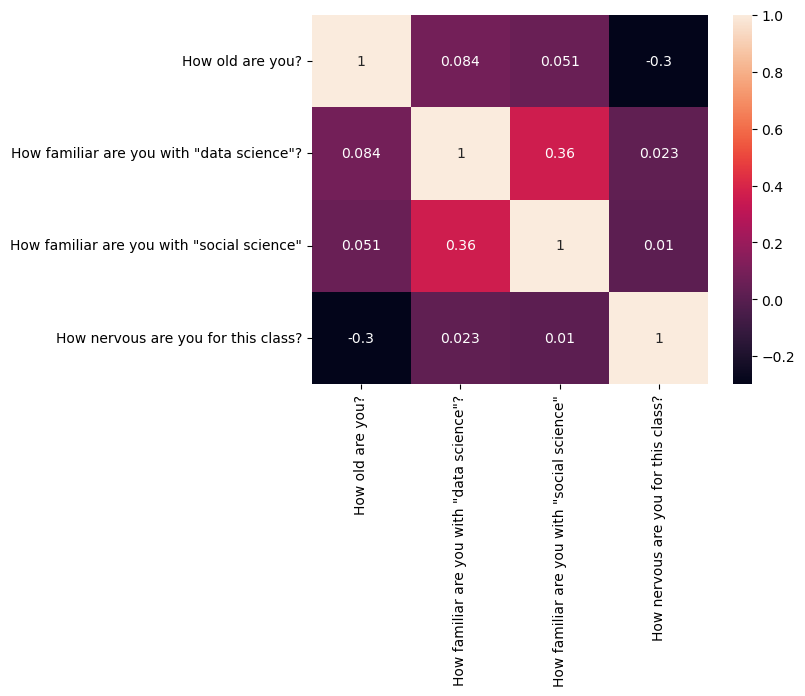

In [21]:
sns.heatmap(df_numeric.corr(), annot=True)

In [22]:
df.columns

Index(['Timestamp', 'What is your name?', 'Did you grow up in North Carolina?',
       'How old are you?', 'What level of a student are you?',
       'How familiar are you with "data science"?',
       'How familiar are you with "social science"',
       'How nervous are you for this class?',
       'Are you excited for this class?',
       'How do you think generative AI should be used or treated in this course? Don't be shy, we're looking for honest, insightful ideas,'],
      dtype='object')

In [23]:
col = ['How familiar are you with "data science"?',
       'How familiar are you with "social science"',
       'How nervous are you for this class?']

([0, 1, 2],
 [Text(0, 0, 'How familiar are you with "data science"?'),
  Text(1, 0, 'How familiar are you with "social science"'),
  Text(2, 0, 'How nervous are you for this class?')])

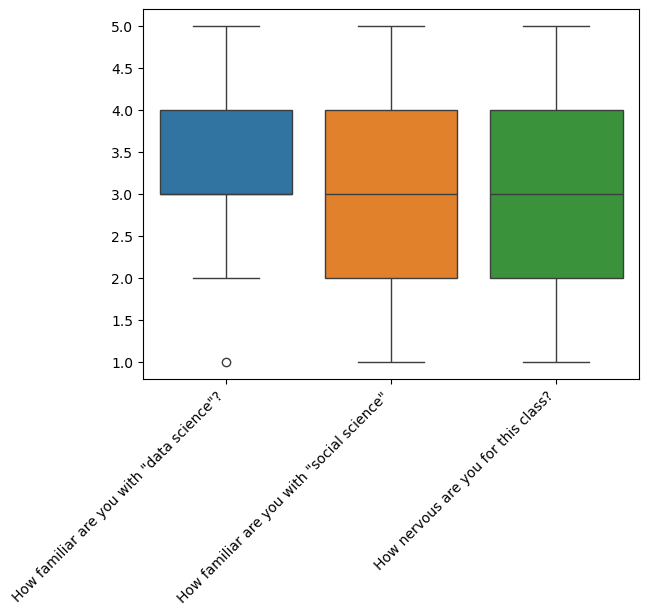

In [24]:
sns.boxplot(data=df[col])
plt.xticks(rotation=45, ha='right')

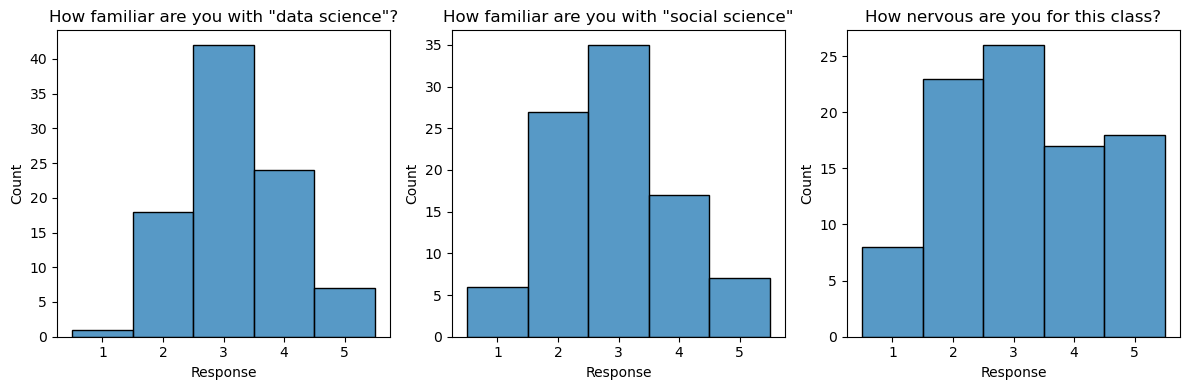

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, q in zip(axes, col):
    sns.histplot(df[q], bins=5, discrete=True, ax=ax)
    ax.set_title(q)
    ax.set_xlabel('Response')

plt.tight_layout()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv(r'/Users/krishikasandiri/Desktop/ds-studio-ii:/datasets/background survey.csv')
columns = ['How familiar are you with "data science"?', 'How nervous are you for this class?']
df = df[columns]
df = df.apply(pd.to_numeric, errors="coerce")
df = df.dropna()

In [8]:
familiarity_avg = df['How familiar are you with "data science"?'].mean()
nervousness_avg = df['How nervous are you for this class?'].mean()
labels = ["Familiarity with Data Science", "Nervousness for This Class"]
values = [familiarity_avg, nervousness_avg]

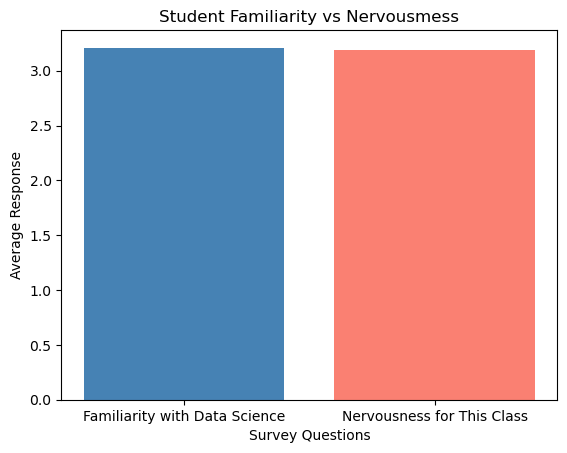

In [9]:
plt.figure()
plt.bar(labels, values, color=["steelblue", "salmon"])
plt.xlabel("Survey Questions")
plt.ylabel("Average Response")
plt.title("Student Familiarity vs Nervousmess")
plt.show()